Full name: Elsa Ingrid Daniela Erkfeldt
Civic registration number: 200309021228
LLM use: No LLM used in this assignment

Installations:

In [ ]:
!pip install -y matplotlib
!pip install -y numpy
!pip install -y scipy  
!pip install -y statsmodels
!pip install -y tensorflow


Import

In [ ]:
import matplotlib.pyplot as plt
import csv
import numpy as np 
from scipy.optimize import minimize
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.stattools import adfuller
import tensorflow.keras.models as models
import tensorflow.keras.layers as layers
import tensorflow.keras.callbacks as callbacks


Write Python code for reading and visualizing the time series data contained in the
files A1_Training, A1_Validation.txt, and A1_Test.txt

In [ ]:
training = []
validation = []
testing = []


with open('A1_training.txt') as training_file:
    plotting = csv.reader(training_file, delimiter='\t')

    for row in plotting:
        training.append(float(row[0]))

with open('A1_validation.txt') as validation_file:
    plotting = csv.reader(validation_file, delimiter='\t')

    for row in plotting:
        validation.append(float(row[0]))

with open('A1_test.txt') as test_file:
    plotting = csv.reader(test_file, delimiter='\t')

    for row in plotting:
        testing.append(float(row[0]))


training = np.array(training)
validation = np.array(validation)
testing = np.array(testing)


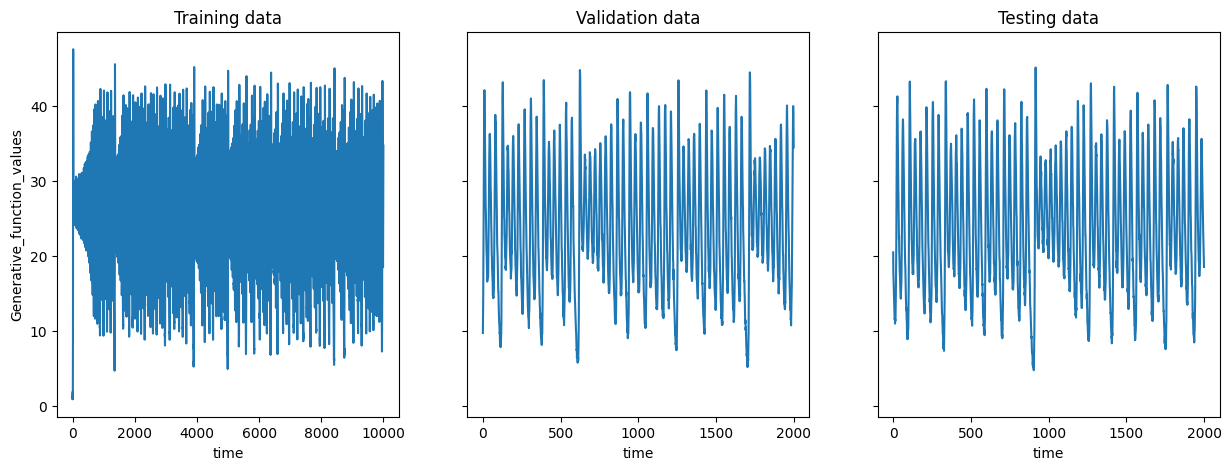

In [ ]:
fig, axs = plt.subplots(1, 3, figsize=(15, 5), sharey=True)

axs[0].plot(training)

axs[0].set_ylabel('Generative_function_values')
axs[0].set_xlabel('time')
axs[0].set_title("Training data")


axs[1].plot(validation)

axs[1].set_xlabel('time')
axs[1].set_title("Validation data")

axs[2].plot(testing)

axs[2].set_xlabel('time')
axs[2].set_title("Testing data")

plt.show()

Fit ARMA model to training data. 
Use Nelder-Mead approach (in scipy.iptimize, set method to Nelder-Mead)
Output: plot showing the test data series and fit that was obtained from ARMA model over that set.
RMSE should be printed (as text)

One method (arma_inference) for making predictions and
one for computing loss function (arma_loss)
use res = minimize(arma_loss, np.zeros(p+q), method='Nelder-Mead', tol=1e-4)

In [ ]:
def arma_loss(params, p, q, training):

    phi = params[2:p+2]
    theta = params[p+2:p+q+2]
    c = params[0]
    sigma2 = params[1]
    
    predicted = np.zeros_like(training)
    error = np.zeros_like(training)

    for t in range(max(p,q), len(training)):
        next = c
        for i in range(len(phi)):
            next += phi[i] * training[t - i - 1]
        for j in range(len(theta)):
            next += theta[j] * error[t - j - 1]
        predicted[t] = next
        error[t] = training[t] - predicted[t]
    
    n = len(training) - max(p, q)
    if sigma2 <= 0:
        return np.inf

    log_likelihood = - (n/2) * np.log(2 * np.pi) - (n/2) * np.log(sigma2) - (1/(2*sigma2)) * np.sum(error[max(p,q):]**2)
    return -log_likelihood


def arma_inference(training, p, q):

    initial_params = np.full(p+q+2, 0.1)
    res = minimize(arma_loss, initial_params, args = (p, q, training), method='Nelder-Mead', tol=1e-4)

    return(res)

p = 2
q = 2


res = arma_inference(training, p, q)
print(res)


C:\Users\Min Dator\AppData\Local\Temp\ipykernel_2712\1604046495.py:26: RuntimeWarning: overflow encountered in square
  log_likelihood = - (n/2) * np.log(2 * np.pi) - (n/2) * np.log(sigma2) - (1/(2*sigma2)) * np.sum(error[max(p,q):]**2)
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)
C:\Users\Min Dator\AppData\Local\Temp\ipykernel_2712\1604046495.py:18: RuntimeWarning: overflow encountered in scalar add
  next += theta[j] * error[t - j - 1]


       message: Optimization terminated successfully.
       success: True
        status: 0
           fun: 12388.060503181066
             x: [ 1.149e+00  7.285e-01  1.885e+00 -9.317e-01 -5.815e-01
                  3.297e-01]
           nit: 646
          nfev: 1008
 final_simplex: (array([[ 1.149e+00,  7.285e-01, ..., -5.815e-01,
                         3.297e-01],
                       [ 1.149e+00,  7.286e-01, ..., -5.815e-01,
                         3.297e-01],
                       ...,
                       [ 1.149e+00,  7.285e-01, ..., -5.815e-01,
                         3.297e-01],
                       [ 1.149e+00,  7.286e-01, ..., -5.814e-01,
                         3.297e-01]], shape=(7, 6)), array([ 1.239e+04,  1.239e+04,  1.239e+04,  1.239e+04,
                        1.239e+04,  1.239e+04,  1.239e+04]))


Graph

RMSE: 0.9094541021318719


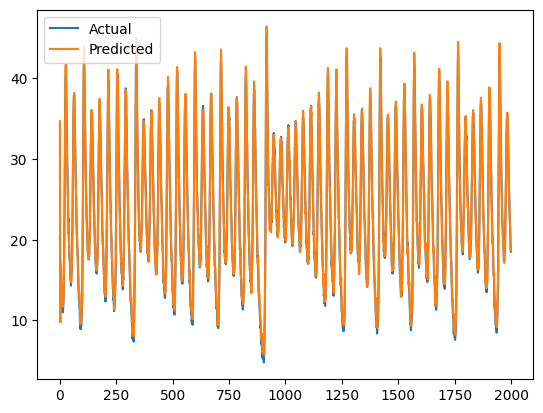

In [ ]:
def arma_calculation(params, p, q, length, training, testing):

    phi = params[2:p+2]
    theta = params[p+2:p+q+2]
    c = params[0]
    
    predicted = np.zeros(length)
    #error = np.zeros_like(training)
    error = np.zeros(length)
    #predicted[:max(p, q)] = training[-max(p, q):]

    history = list(training[-max(p, q):])

    for t in range(length):
        next = c
        for i in range(p):
            next += phi[i] * history[- i - 1]
        for j in range(q):
            next += theta[j] * error[t - j - 1]
        predicted[t] = next

        error[t] = testing[t] - predicted[t]

        history.append(predicted[t])
    
    return predicted


results = arma_calculation(res.x, p, q, len(testing), training, testing)


rmse = np.sqrt(np.mean((testing - results) ** 2))
print("RMSE:", rmse)
plt.plot(testing, label='Actual')
plt.plot(results, label='Predicted')
plt.legend()
plt.show()


Investigate Autocorrelation function (ACF) and the partial autocorrelation function (PACF) of series.
Use this to identify good pa dn 1 values
Include the ACF and PACF plots
Finally, select the p and q for whihc the RMSE over the validation set is minimal (after fitting the ARMA model over the trainign set)

<Figure size 640x480 with 0 Axes>

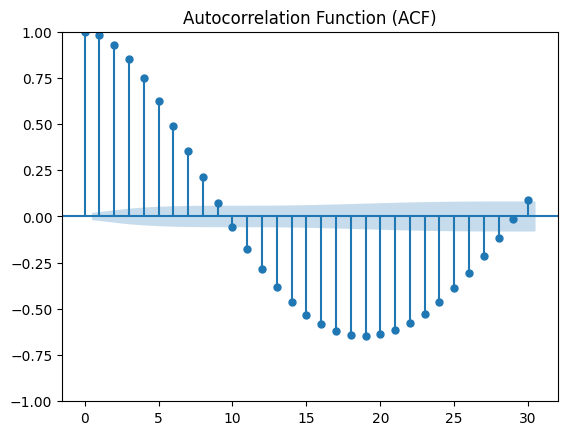

<Figure size 640x480 with 0 Axes>

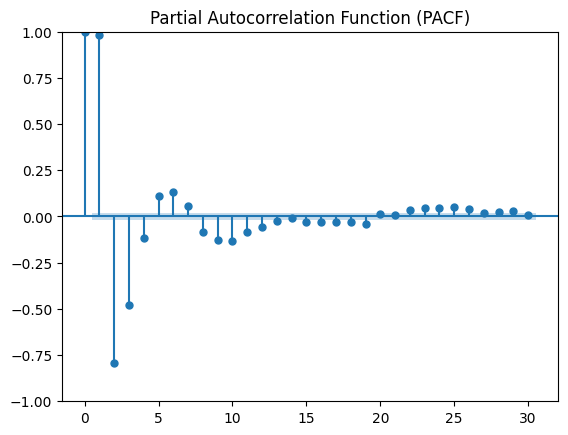

In [ ]:
def plotting_ACF_and_PACF(data):
    data_array = np.array(data)

    data0 = data_array - np.mean(data_array)


    plt.figure()
    plot_acf(data0, lags=30)
    plt.title('Autocorrelation Function (ACF)')
    plt.show()

    plt.figure()
    plot_pacf(data0, lags=30)
    plt.title('Partial Autocorrelation Function (PACF)')
    plt.show()

plotting_ACF_and_PACF(training)


None of them cross the cutoff early, instead they slowly decrease.
They therefore do not provide clear, unambigious values for p and q, thus indicating that using RMSE over a validation set to find the p and q values which minimise RMSE mgith be more useful. 

In [ ]:

params = res.x

results = []
for p in range(0,5):
    for q in range(0,5):
        if p == 0 and q == 0:
            continue
        res = arma_inference(training, p, q)
        pred_val = arma_calculation(res.x, p, q, len(validation), training, validation)

        val_rmse = np.sqrt(np.mean((validation - pred_val) ** 2))
        results.append((val_rmse, p, q))
        print(val_rmse, p, q)

results.sort()
best_rmse, best_p, best_q = results[0]
print(f"Best RMSE: {best_rmse} with p={best_p} and q={best_q}")


res_final = arma_inference(training, best_p, best_q)
pred_test = arma_calculation(res_final.x, best_p, best_q, len(testing), training, testing)
rmse_test = np.sqrt(np.mean((testing - pred_test) ** 2))
print(f"Test RMSE: {rmse_test}") 

plt.figure()
plt.plot(testing, label='Actual')
plt.plot(pred_test, label='Predicted')
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Predicted vs. Actual for ARMA, RMSE={rmse_test:.4f}')
plt.legend()
plt.show()


C:\Users\Min Dator\AppData\Local\Temp\ipykernel_2712\1604046495.py:18: RuntimeWarning: overflow encountered in scalar multiply
  next += theta[j] * error[t - j - 1]
C:\Users\Min Dator\AppData\Local\Temp\ipykernel_2712\1604046495.py:26: RuntimeWarning: overflow encountered in square
  log_likelihood = - (n/2) * np.log(2 * np.pi) - (n/2) * np.log(sigma2) - (1/(2*sigma2)) * np.sum(error[max(p,q):]**2)
c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\numpy\_core\fromnumeric.py:86: RuntimeWarning: overflow encountered in reduce
  return ufunc.reduce(obj, axis, dtype, out, **passkwargs)


4.631433295281031 0 1


C:\Users\Min Dator\AppData\Local\Temp\ipykernel_2712\1604046495.py:18: RuntimeWarning: invalid value encountered in scalar add
  next += theta[j] * error[t - j - 1]
C:\Users\Min Dator\AppData\Local\Temp\ipykernel_2712\1604046495.py:18: RuntimeWarning: overflow encountered in scalar add
  next += theta[j] * error[t - j - 1]


2.9357420621360504 0 2
5.215646168078831 0 3
3.914637044697003 0 4
1.761369782146338 1 0
1.4730847891128245 1 1
1.3255539613177634 1 2
1.305386573884925 1 3
1.246409883219733 1 4
1.2041104107510279 2 0
1.53123672280859 2 1
1.0728559918181106 2 2
1.3149404573776189 2 3
1.1919136186151016 2 4
1.1641933185014168 3 0
1.0685635999935652 3 1
1.1550631427798506 3 2
1.2065933564285187 3 3
1.3078969123398227 3 4
1.1326796122397573 4 0
1.6236542527260993 4 1
1.1074051514909795 4 2
1.1222184762859246 4 3
2.2493599405620506 4 4
Best RMSE: 1.0685635999935652 with p=3 and q=1


3, 1, np.float64(2456.6352909031975)
So p = 3 and q = 1

Train a single-layer LSTM network to predict the data series (eg. using LSTM subpackage of Keras).
- Use Adam optimiser with MSE loss function
-Use tanh activation function for the LSTM units
-Use holdout validation
    -Ie train over the training set and use the loss over the validation set to determine when to stop training.

Epoch 1/50


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


312/312 ━━━━━━━━━━━━━━━━━━━━ 51s 6ms/step - loss: 342.5820 - val_loss: 159.0085
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 108.0616 - val_loss: 69.2314
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 48.7652 - val_loss: 33.1355
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 23.9593 - val_loss: 16.9405
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 12.5649 - val_loss: 9.0305
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 6.9886 - val_loss: 5.2439
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 4.1500 - val_loss: 3.2049
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 2.6349 - val_loss: 2.1452
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 1.7744 - val_loss: 1.4856
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.2805 - val_loss: 1.1208
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.9778 - val_loss: 0.8536
Epoch 12/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/s

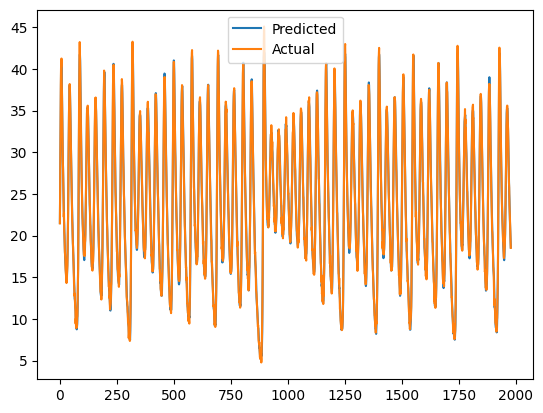

Rmse is 0.5625331387238938


In [ ]:
window_size = 20

def create_window(data, window_size):
    X, Y = [], []
    for i in range(len(data) - window_size):
        X.append(data[i: i + window_size]) #Past values
        Y.append(data[i + window_size]) #New value
    return np.array(X), np.array(Y)

X_train, y_train = create_window(training, window_size)
X_validation, y_validation = create_window(validation, window_size)
X_test, y_test = create_window(testing, window_size)

X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

lstm = models.Sequential([
    layers.LSTM(32, activation = 'tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

holdout = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
historical_data = lstm.fit(X_train, y_train, epochs = 50, batch_size=32, validation_data=(X_validation, y_validation), callbacks=[holdout])
predicted_values = lstm.predict(X_test)
 

plt.figure()
plt.plot(predicted_values, label='Predicted')
plt.plot(y_test, label='Actual')
plt.legend()
plt.show()

def calculate_rmse(predicted, actual):
    error = actual - predicted
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    return rmse

print(f"Rmse is {calculate_rmse(predicted_values.flatten(), y_test)}")

I then tried with a few different settings to see if I could get better results

Epoch 1/50


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


625/625 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 388.4975 - val_loss: 204.6125
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 137.5421 - val_loss: 83.0336
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - loss: 49.6123 - val_loss: 28.6284
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - loss: 19.1700 - val_loss: 12.3438
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 8.6417 - val_loss: 5.7703
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 4.1746 - val_loss: 2.8891
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 2.2081 - val_loss: 1.7459
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 6s 8ms/step - loss: 1.3551 - val_loss: 1.1455
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.9035 - val_loss: 0.7641
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - loss: 0.6786 - val_loss: 0.5637
Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.5346 - val_loss: 0.5744
Epoch 12/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/st

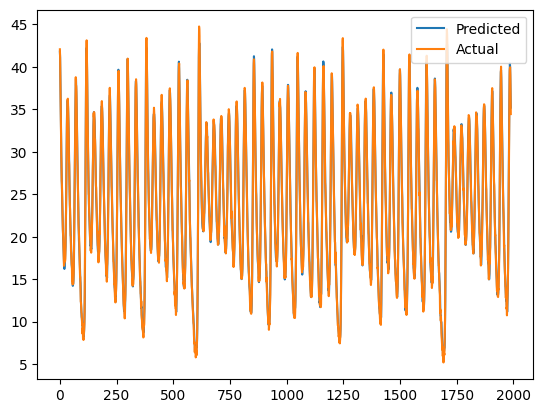

Rmse is 0.5418567693086231
Epoch 1/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 301.1308 - val_loss: 154.6376
Epoch 2/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 103.6346 - val_loss: 64.5366
Epoch 3/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 7s 11ms/step - loss: 43.7623 - val_loss: 28.1119
Epoch 4/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 19.3841 - val_loss: 12.6659
Epoch 5/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 9.0805 - val_loss: 6.1592
Epoch 6/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 11ms/step - loss: 4.5955 - val_loss: 3.1979
Epoch 7/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 2.5412 - val_loss: 1.8786
Epoch 8/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 1.5139 - val_loss: 1.2995
Epoch 9/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 1.0071 - val_loss: 0.8169
Epoch 10/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.7255 - val_loss: 0.6582
Epoch 11/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.5642 - val_loss: 0.488

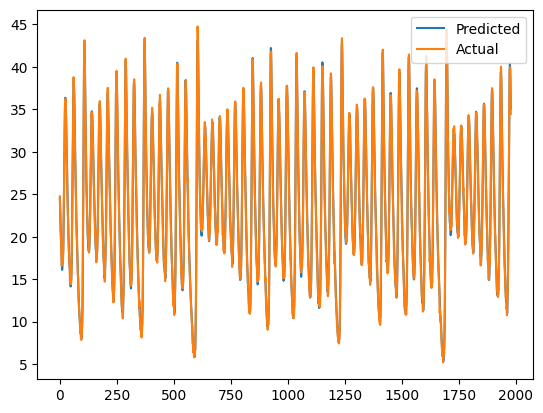

Rmse is 0.5109761250400421
Epoch 1/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - loss: 375.2966 - val_loss: 208.3291
Epoch 2/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 141.0751 - val_loss: 91.6766
Epoch 3/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 63.4893 - val_loss: 42.5656
Epoch 4/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 29.5591 - val_loss: 19.5262
Epoch 5/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 11.7620 - val_loss: 6.8679
Epoch 6/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 4.8656 - val_loss: 3.3864
Epoch 7/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 2.5183 - val_loss: 1.9509
Epoch 8/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 1.4730 - val_loss: 1.1818
Epoch 9/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.9615 - val_loss: 0.8629
Epoch 10/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.6834 - val_loss: 0.5962
Epoch 11/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.5519 - val_loss: 0.5164
Epoch 12/50
6

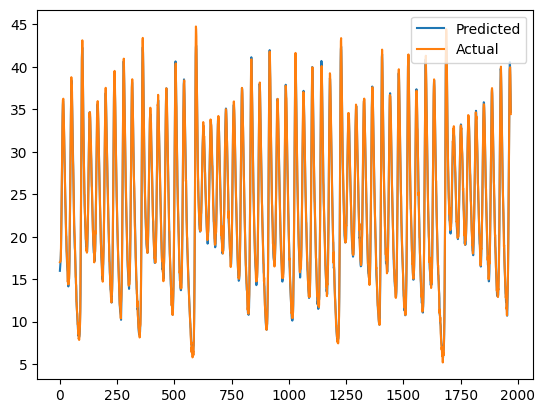

Rmse is 0.529172103390281
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 415.2907 - val_loss: 286.7894
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 215.8511 - val_loss: 164.5018
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 131.8973 - val_loss: 104.3085
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 84.4214 - val_loss: 67.7723
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 55.0365 - val_loss: 44.6049
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 35.9258 - val_loss: 26.5027
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 20.4806 - val_loss: 15.9692
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 12.8456 - val_loss: 10.2505
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 8.4400 - val_loss: 6.8603
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 5.6943 - val_loss: 4.6706
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 3.9465 - val_loss: 3.2825
Epoc

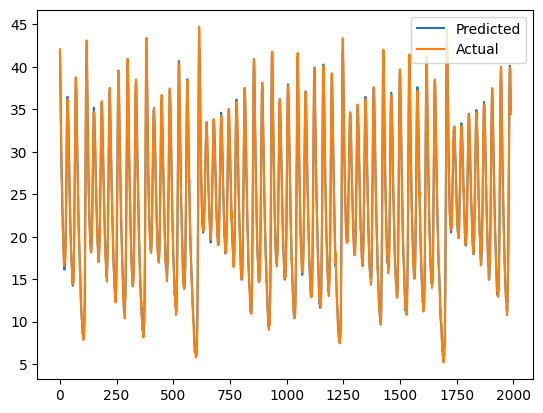

Rmse is 0.5335776696352232
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 455.7574 - val_loss: 292.6023
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 227.0398 - val_loss: 174.3482
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 140.6643 - val_loss: 110.6416
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 89.9068 - val_loss: 71.4993
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 58.6115 - val_loss: 47.0745
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 38.7941 - val_loss: 31.4442
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 25.9982 - val_loss: 21.0871
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 17.5760 - val_loss: 14.2919
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 12.0135 - val_loss: 9.7818
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 8.3139 - val_loss: 6.8310
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 5.7999 - val_loss: 4.7716
Ep

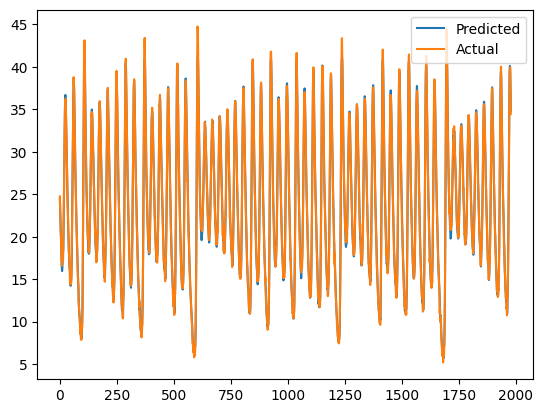

Rmse is 0.5597647482502635
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - loss: 415.4929 - val_loss: 241.4542
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 179.6346 - val_loss: 134.7409
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 105.9913 - val_loss: 81.9104
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 64.5347 - val_loss: 50.6258
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - loss: 40.2534 - val_loss: 32.1132
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 25.6978 - val_loss: 20.5752
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 16.7447 - val_loss: 13.5338
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 11.1332 - val_loss: 9.0184
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 7.5615 - val_loss: 6.1955
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 5.2409 - val_loss: 4.3495
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 3.7290 - val_loss: 3.1335
Epoch

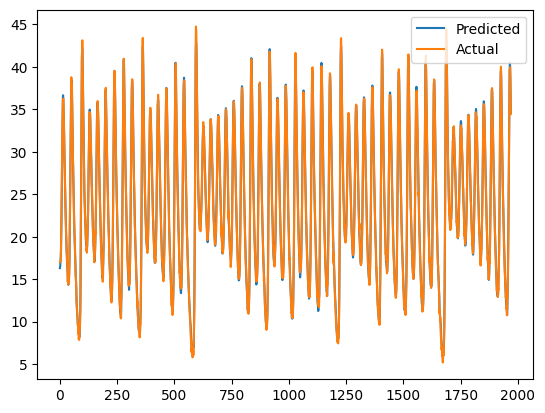

Rmse is 0.508125977051213
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - loss: 520.3669 - val_loss: 433.6556
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 358.0583 - val_loss: 270.7091
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 230.0003 - val_loss: 198.9978
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 175.8132 - val_loss: 153.2681
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 132.8985 - val_loss: 115.6029
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 102.2294 - val_loss: 90.2598
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 80.3121 - val_loss: 71.3753
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 63.6543 - val_loss: 56.9523
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 50.7489 - val_loss: 45.5886
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 40.6367 - val_loss: 36.5810
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 32.7041 - val_loss: 2

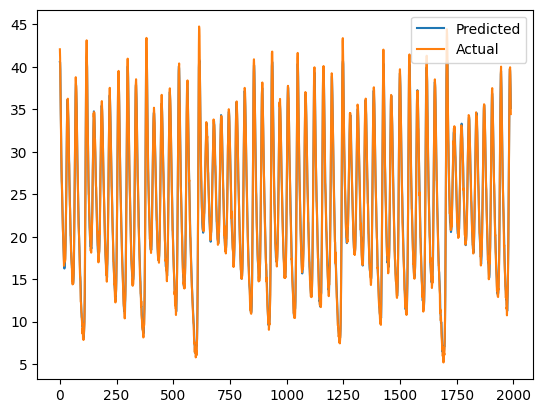

Rmse is 0.5927514916310836
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - loss: 501.7010 - val_loss: 388.3466
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 341.4791 - val_loss: 288.1203
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 258.1526 - val_loss: 228.7345
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 207.2876 - val_loss: 185.5254
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 169.2056 - val_loss: 152.3624
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 138.8795 - val_loss: 124.6152
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 113.6718 - val_loss: 102.1260
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 93.3481 - val_loss: 84.1216
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 77.0300 - val_loss: 69.6686
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 63.7711 - val_loss: 57.7845
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 52.8953 - val_los

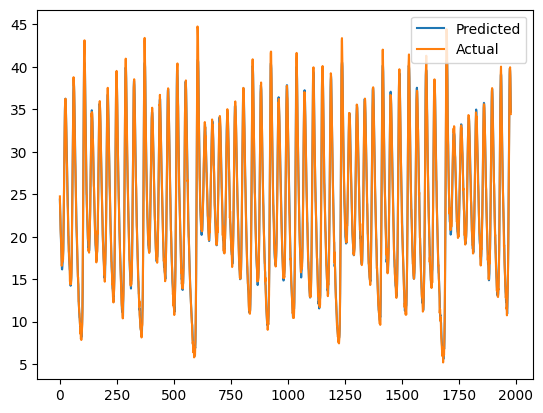

Rmse is 0.5849302950921491
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 560.5371 - val_loss: 442.5030
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 348.8286 - val_loss: 289.1552
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 255.8009 - val_loss: 225.2113
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 200.8589 - val_loss: 178.3853
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 159.8717 - val_loss: 142.7461
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 128.4048 - val_loss: 115.3092
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 103.9597 - val_loss: 93.6623
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 13ms/step - loss: 84.1230 - val_loss: 75.5071
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 67.8143 - val_loss: 61.1664
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 55.0175 - val_loss: 49.8287
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 44.7781 - v

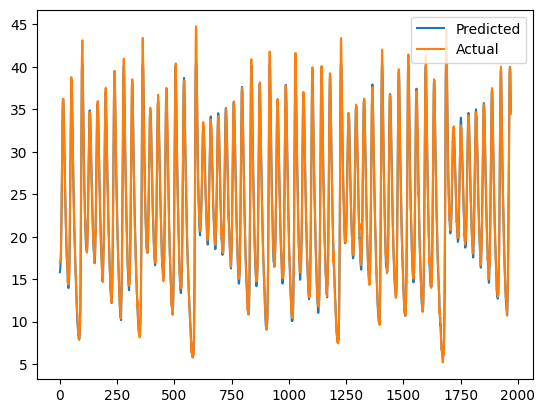

Rmse is 0.6057501763186729
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 4ms/step - loss: 212.8397 - val_loss: 56.1396
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 27.8958 - val_loss: 12.2589
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 7.1111 - val_loss: 3.8041
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 2.4863 - val_loss: 1.5896
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 1.1802 - val_loss: 0.8758
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.7254 - val_loss: 0.6540
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.5474 - val_loss: 0.4677
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4463 - val_loss: 0.4099
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.4081 - val_loss: 0.3690
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - loss: 0.3655 - val_loss: 0.3406
Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 5s 7ms/step - loss: 0.3521 - val_loss: 0.3960
Epoch 12/50
625/625 

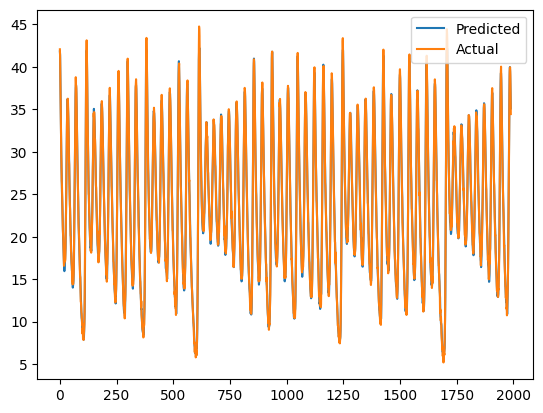

Rmse is 0.5367504581310852
Epoch 1/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 195.4637 - val_loss: 59.7939
Epoch 2/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 29.2857 - val_loss: 12.2902
Epoch 3/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 7.0067 - val_loss: 3.6249
Epoch 4/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 10ms/step - loss: 2.4345 - val_loss: 1.5682
Epoch 5/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 10ms/step - loss: 1.1802 - val_loss: 0.9501
Epoch 6/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 9ms/step - loss: 0.7325 - val_loss: 0.7449
Epoch 7/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.5485 - val_loss: 0.4838
Epoch 8/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.4513 - val_loss: 0.4598
Epoch 9/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 0.4058 - val_loss: 0.3752
Epoch 10/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 4s 6ms/step - loss: 0.3693 - val_loss: 0.4293
Epoch 11/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 0.3537 - val_loss: 0.3345
Epoch 12/

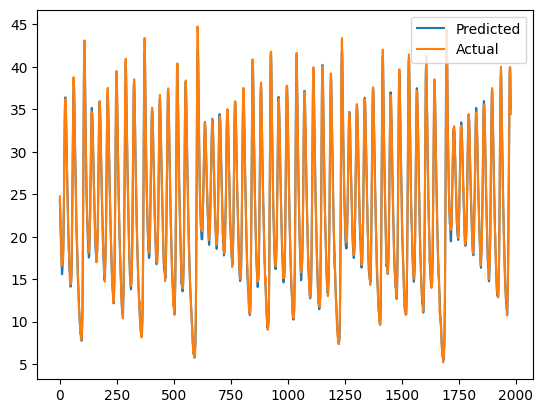

Rmse is 0.5763242439812561
Epoch 1/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 16s 20ms/step - loss: 190.4476 - val_loss: 58.2431
Epoch 2/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 29.5441 - val_loss: 13.3072
Epoch 3/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 7.6515 - val_loss: 4.2009
Epoch 4/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 2.6549 - val_loss: 1.6441
Epoch 5/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 1.2521 - val_loss: 0.9856
Epoch 6/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 21s 19ms/step - loss: 0.7634 - val_loss: 0.6294
Epoch 7/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 20s 18ms/step - loss: 0.5519 - val_loss: 0.5767
Epoch 8/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 0.4405 - val_loss: 0.4448
Epoch 9/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 12s 18ms/step - loss: 0.4074 - val_loss: 0.3714
Epoch 10/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 11s 18ms/step - loss: 0.3668 - val_loss: 0.3357
Epoch 11/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 0.3510 - val_loss: 0.301

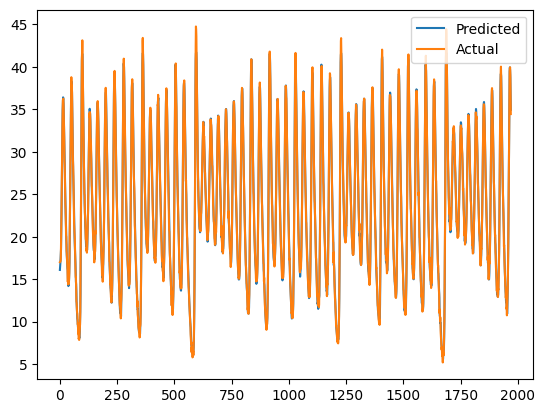

Rmse is 0.5494131831999111
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 13ms/step - loss: 330.2020 - val_loss: 139.1259
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 88.9277 - val_loss: 55.0043
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 37.3756 - val_loss: 24.7347
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 17.5132 - val_loss: 12.1266
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - loss: 8.9486 - val_loss: 6.4664
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 4.9346 - val_loss: 3.7142
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 9ms/step - loss: 2.9103 - val_loss: 2.2441
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 1.8502 - val_loss: 1.5059
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 1.2662 - val_loss: 1.1140
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - loss: 0.9421 - val_loss: 0.8012
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 0.7002 - val_loss: 0.7075
Epoch 

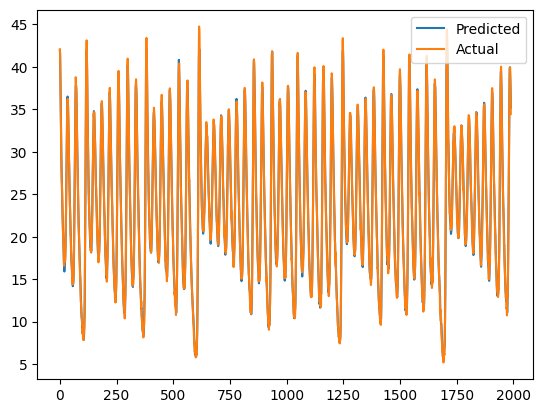

Rmse is 0.548602941532116
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 18ms/step - loss: 316.0434 - val_loss: 128.2645
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 82.7859 - val_loss: 49.8403
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 33.8172 - val_loss: 22.0715
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 15.5638 - val_loss: 10.5676
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 11s 19ms/step - loss: 7.8725 - val_loss: 5.6031
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 15ms/step - loss: 4.3300 - val_loss: 3.2232
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 14ms/step - loss: 2.6193 - val_loss: 2.0488
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 1.7108 - val_loss: 1.4289
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 1.2111 - val_loss: 1.0734
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - loss: 0.9164 - val_loss: 0.7779
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step - loss: 0.7195 - val_loss: 0.6598
Epo

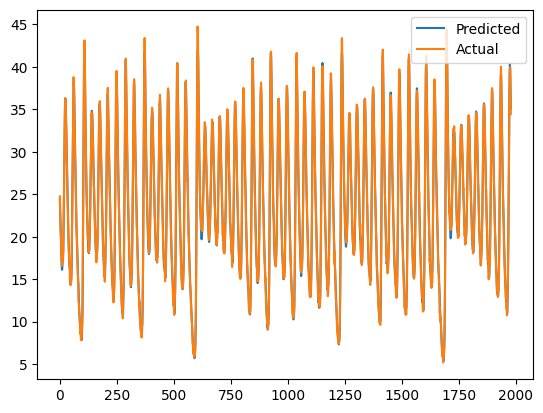

Rmse is 0.551234597721395
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 19ms/step - loss: 330.5811 - val_loss: 152.0754
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 9s 16ms/step - loss: 100.6530 - val_loss: 63.3224
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 43.4679 - val_loss: 29.0771
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 20.7095 - val_loss: 14.4508
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 15ms/step - loss: 10.6797 - val_loss: 7.7338
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 5.8944 - val_loss: 4.3749
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 3.4806 - val_loss: 2.7380
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 2.2299 - val_loss: 1.8025
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 10s 15ms/step - loss: 1.5169 - val_loss: 1.2783
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 5s 16ms/step - loss: 1.0959 - val_loss: 0.9717
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 17ms/step - loss: 0.8442 - val_loss: 0.8137
E

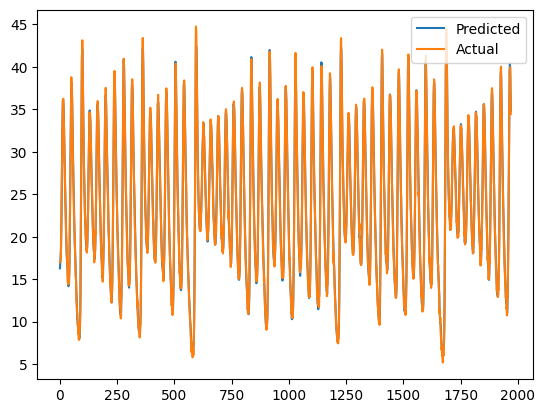

Rmse is 0.517790011381478
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - loss: 387.4839 - val_loss: 230.9501
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 173.3634 - val_loss: 132.8421
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 105.9776 - val_loss: 83.1968
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 66.9126 - val_loss: 53.5145
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 9ms/step - loss: 43.6023 - val_loss: 35.4864
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 29.1613 - val_loss: 23.9945
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 19.9314 - val_loss: 16.5579
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 13.9238 - val_loss: 11.6704
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 9.9316 - val_loss: 8.4182
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - loss: 7.2295 - val_loss: 6.1551
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 5.3737 - val_loss: 4.6

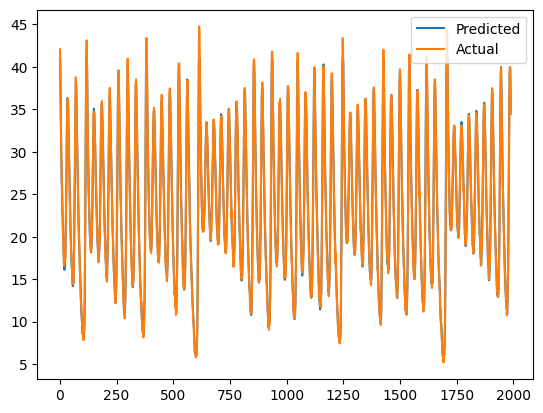

Rmse is 0.556921451561261
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 22ms/step - loss: 486.8144 - val_loss: 281.7029
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 198.6004 - val_loss: 142.1250
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 114.8244 - val_loss: 91.4749
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 19ms/step - loss: 75.3721 - val_loss: 61.1994
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - loss: 50.6095 - val_loss: 41.1101
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 33.4877 - val_loss: 26.7005
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 21.3885 - val_loss: 17.4642
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 14.6612 - val_loss: 12.1506
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 6s 22ms/step - loss: 10.3983 - val_loss: 8.7130
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 17ms/step - loss: 7.5893 - val_loss: 6.4693
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 19ms/step - loss: 5.6759 - val_loss: 

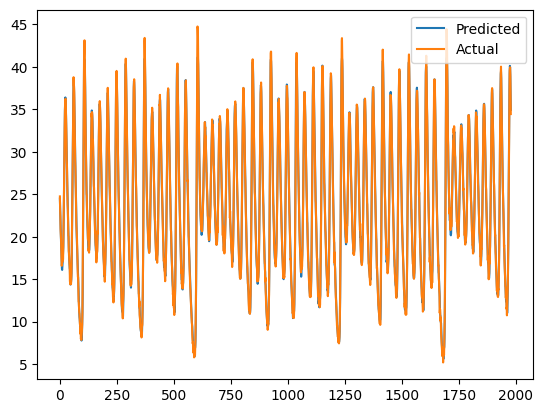

Rmse is 0.5590813309431332
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 28ms/step - loss: 423.7702 - val_loss: 277.1625
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 210.9094 - val_loss: 163.3722
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 133.6577 - val_loss: 108.2260
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 89.4369 - val_loss: 73.3600
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 22ms/step - loss: 61.0731 - val_loss: 50.7679
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 42.5302 - val_loss: 35.7266
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 30.1408 - val_loss: 25.5323
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 21.6440 - val_loss: 18.4595
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 22ms/step - loss: 15.8057 - val_loss: 13.5555
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 3s 20ms/step - loss: 11.6804 - val_loss: 10.0688
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 8.7481 - val_l

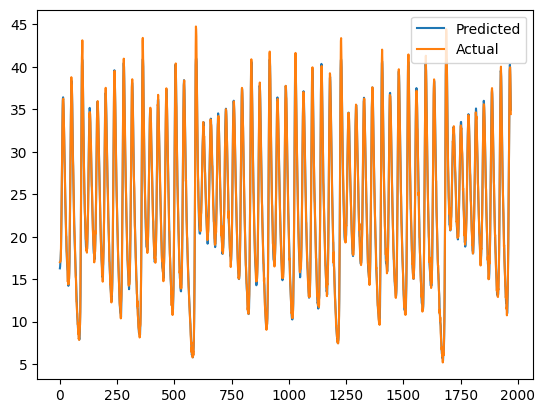

Rmse is 0.5600111121814018
Epoch 1/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 20s 21ms/step - loss: 120.5392 - val_loss: 10.6638
Epoch 2/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 12s 19ms/step - loss: 4.4338 - val_loss: 1.6914
Epoch 3/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 12ms/step - loss: 1.0668 - val_loss: 0.7384
Epoch 4/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - loss: 0.5785 - val_loss: 0.4830
Epoch 5/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - loss: 0.4620 - val_loss: 0.4996
Epoch 6/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - loss: 0.4108 - val_loss: 0.3624
Epoch 7/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 17s 19ms/step - loss: 0.3692 - val_loss: 0.3380
Epoch 8/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.3555 - val_loss: 0.3120
Epoch 9/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 15s 12ms/step - loss: 0.3515 - val_loss: 0.5855
Epoch 10/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 13s 21ms/step - loss: 0.3492 - val_loss: 0.3165
Epoch 11/50
625/625 ━━━━━━━━━━━━━━━━━━━━ 164s 43ms/step - loss: 0.3417 - val_loss: 0.3303

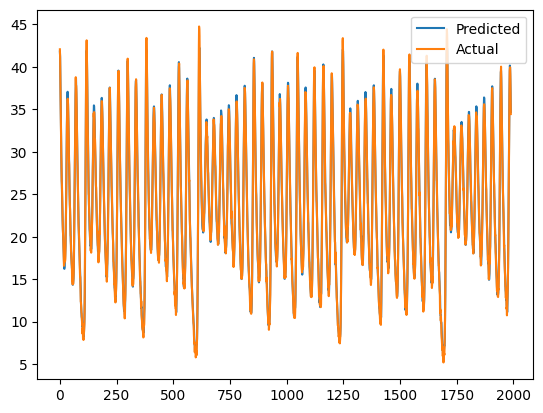

Rmse is 0.5585776040672048
Epoch 1/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 28s 33ms/step - loss: 102.8379 - val_loss: 10.4146
Epoch 2/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - loss: 4.4372 - val_loss: 1.7157
Epoch 3/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 25ms/step - loss: 1.1090 - val_loss: 0.8101
Epoch 4/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 22s 28ms/step - loss: 0.5854 - val_loss: 0.5100
Epoch 5/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 17s 27ms/step - loss: 0.4461 - val_loss: 0.4011
Epoch 6/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 0.3987 - val_loss: 0.3829
Epoch 7/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.3651 - val_loss: 0.3445
Epoch 8/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 19s 30ms/step - loss: 0.3543 - val_loss: 0.3322
Epoch 9/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 21s 31ms/step - loss: 0.3483 - val_loss: 0.3229
Epoch 10/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - loss: 0.3437 - val_loss: 0.3066
Epoch 11/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 21s 29ms/step - loss: 0.3441 - val_loss: 0.2963


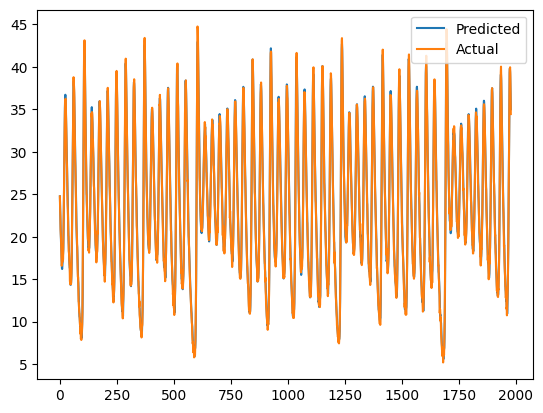

Rmse is 0.5443769944703346
Epoch 1/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 29s 35ms/step - loss: 102.8353 - val_loss: 10.6217
Epoch 2/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 20s 32ms/step - loss: 4.4433 - val_loss: 1.7129
Epoch 3/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 25s 41ms/step - loss: 1.0609 - val_loss: 0.8739
Epoch 4/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 38s 36ms/step - loss: 0.5694 - val_loss: 0.4812
Epoch 5/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 22s 35ms/step - loss: 0.4360 - val_loss: 0.5155
Epoch 6/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 40s 34ms/step - loss: 0.3856 - val_loss: 0.4381
Epoch 7/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - loss: 0.3696 - val_loss: 0.3538
Epoch 8/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - loss: 0.3574 - val_loss: 0.3133
Epoch 9/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - loss: 0.3458 - val_loss: 0.3169
Epoch 10/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - loss: 0.3438 - val_loss: 0.3148
Epoch 11/50
624/624 ━━━━━━━━━━━━━━━━━━━━ 38s 35ms/step - loss: 0.3358 - val_loss: 0.2975


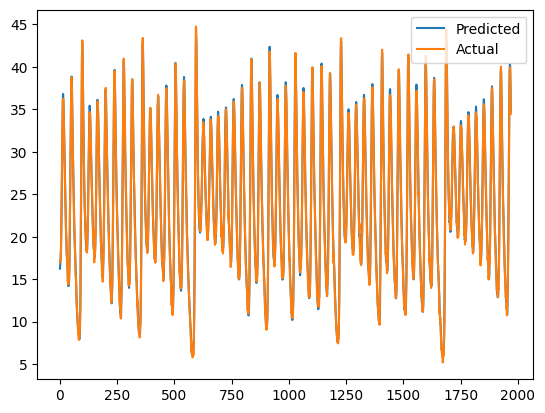

Rmse is 0.5323816399894669
Epoch 1/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 13s 27ms/step - loss: 189.6326 - val_loss: 53.0621
Epoch 2/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 10s 26ms/step - loss: 25.6582 - val_loss: 11.1053
Epoch 3/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 21ms/step - loss: 6.4904 - val_loss: 3.3334
Epoch 4/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 20ms/step - loss: 2.1880 - val_loss: 1.4195
Epoch 5/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 14ms/step - loss: 1.1138 - val_loss: 0.9079
Epoch 6/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 7s 23ms/step - loss: 0.7431 - val_loss: 0.6806
Epoch 7/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 11ms/step - loss: 0.5742 - val_loss: 0.4850
Epoch 8/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.4648 - val_loss: 0.4469
Epoch 9/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step - loss: 0.4161 - val_loss: 0.4035
Epoch 10/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 9s 29ms/step - loss: 0.3864 - val_loss: 0.3797
Epoch 11/50
313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 25ms/step - loss: 0.3599 - val_loss: 0.3295
Epoch 1

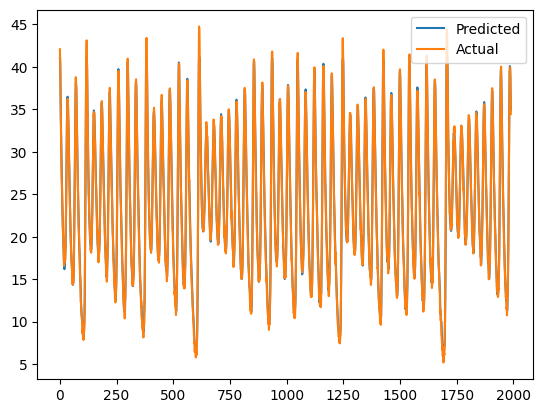

Rmse is 0.5740471333410455
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 19s 47ms/step - loss: 198.8858 - val_loss: 41.4884
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 11s 36ms/step - loss: 20.0662 - val_loss: 8.3896
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 22ms/step - loss: 4.9461 - val_loss: 2.8004
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 1.9343 - val_loss: 1.3405
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 1.0508 - val_loss: 0.9178
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 26s 56ms/step - loss: 0.7226 - val_loss: 0.6274
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 40ms/step - loss: 0.5617 - val_loss: 0.5205
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 13s 41ms/step - loss: 0.4626 - val_loss: 0.4215
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 0.4241 - val_loss: 0.3997
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 38ms/step - loss: 0.4017 - val_loss: 0.4459
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 37ms/step - loss: 0.3579 - val_loss: 0.3330

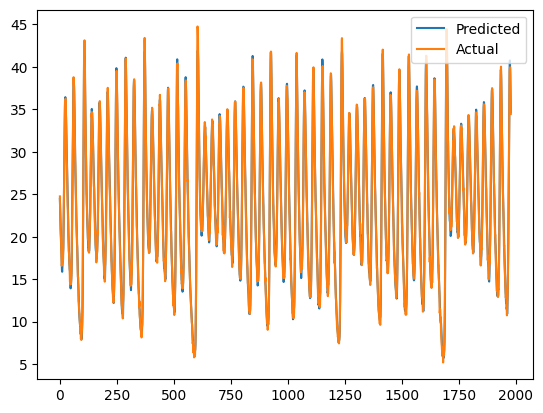

Rmse is 0.5501909805986754
Epoch 1/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 24s 54ms/step - loss: 188.1915 - val_loss: 42.3100
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 33s 106ms/step - loss: 21.0279 - val_loss: 9.5389
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 12s 38ms/step - loss: 5.6081 - val_loss: 3.1365
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 53ms/step - loss: 2.1522 - val_loss: 1.4992
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - loss: 1.1522 - val_loss: 0.8967
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 0.7605 - val_loss: 0.6648
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 19s 44ms/step - loss: 0.5680 - val_loss: 0.6090
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 51ms/step - loss: 0.4658 - val_loss: 0.4297
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 15s 34ms/step - loss: 0.4187 - val_loss: 0.4020
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 16s 49ms/step - loss: 0.3877 - val_loss: 0.3537
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 17s 52ms/step - loss: 0.3567 - val_loss: 0.339

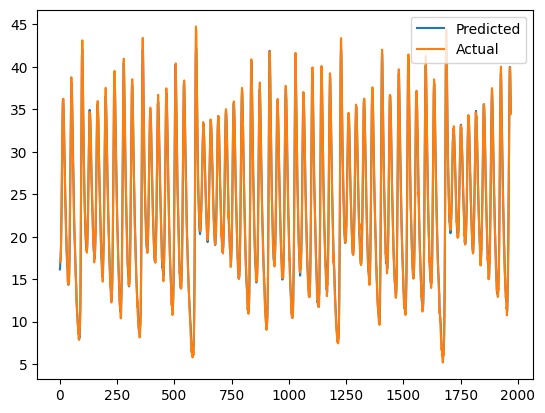

Rmse is 0.5243818004677444
Epoch 1/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 10s 39ms/step - loss: 291.5902 - val_loss: 113.8975
Epoch 2/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 30ms/step - loss: 69.1608 - val_loss: 40.6725
Epoch 3/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 5s 34ms/step - loss: 25.9879 - val_loss: 16.1426
Epoch 4/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step - loss: 11.4274 - val_loss: 7.9029
Epoch 5/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 23ms/step - loss: 5.9412 - val_loss: 4.3390
Epoch 6/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 12ms/step - loss: 3.4459 - val_loss: 2.6813
Epoch 7/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 24ms/step - loss: 2.1888 - val_loss: 1.7571
Epoch 8/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 13ms/step - loss: 1.5054 - val_loss: 1.3480
Epoch 9/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 28ms/step - loss: 1.1068 - val_loss: 1.0006
Epoch 10/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - loss: 0.8735 - val_loss: 0.7889
Epoch 11/50
157/157 ━━━━━━━━━━━━━━━━━━━━ 4s 26ms/step - loss: 0.7254 - val_loss: 0.6560
Epoc

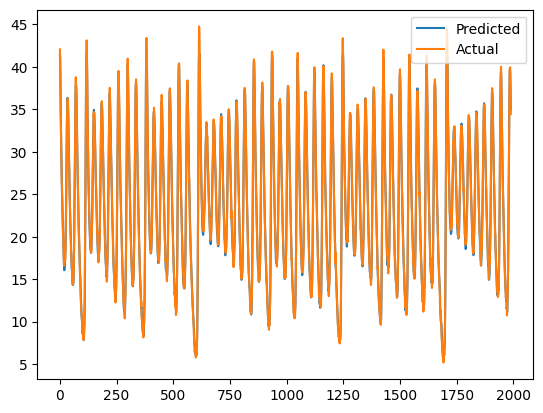

Rmse is 0.5513410866222034
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 15s 58ms/step - loss: 300.9144 - val_loss: 123.0455
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 50ms/step - loss: 77.5780 - val_loss: 45.2356
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 48ms/step - loss: 30.5174 - val_loss: 19.4405
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 13.9140 - val_loss: 9.4817
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 45ms/step - loss: 7.1102 - val_loss: 5.1047
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 13s 62ms/step - loss: 4.0613 - val_loss: 3.0856
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 59ms/step - loss: 2.5562 - val_loss: 2.0546
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 49ms/step - loss: 1.7373 - val_loss: 1.4716
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 7s 45ms/step - loss: 1.2654 - val_loss: 1.0997
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 54ms/step - loss: 1.0052 - val_loss: 0.8885
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 5s 23ms/step - loss: 0.8043 - val_loss: 0.7168
E

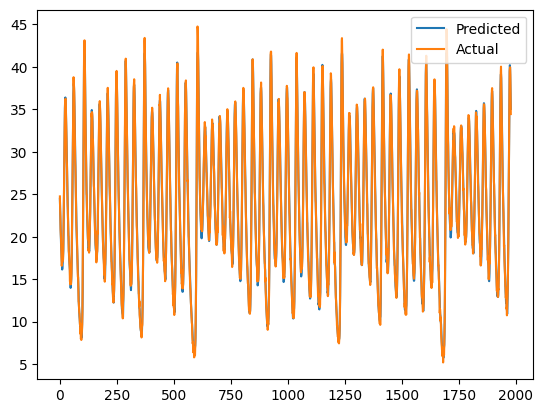

Rmse is 0.5318654534295791
Epoch 1/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 17s 69ms/step - loss: 330.1649 - val_loss: 133.8767
Epoch 2/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 15s 35ms/step - loss: 85.7795 - val_loss: 49.1712
Epoch 3/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 34ms/step - loss: 31.1266 - val_loss: 19.6676
Epoch 4/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 33ms/step - loss: 13.7086 - val_loss: 9.3778
Epoch 5/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 60ms/step - loss: 6.9242 - val_loss: 5.1096
Epoch 6/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 57ms/step - loss: 3.8805 - val_loss: 2.9843
Epoch 7/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 8s 40ms/step - loss: 2.4188 - val_loss: 2.0372
Epoch 8/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 10s 40ms/step - loss: 1.6640 - val_loss: 1.4104
Epoch 9/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 33ms/step - loss: 1.2229 - val_loss: 1.0662
Epoch 10/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 11s 35ms/step - loss: 0.9535 - val_loss: 0.8555
Epoch 11/50
156/156 ━━━━━━━━━━━━━━━━━━━━ 9s 57ms/step - loss: 0.7577 - val_loss: 0.699

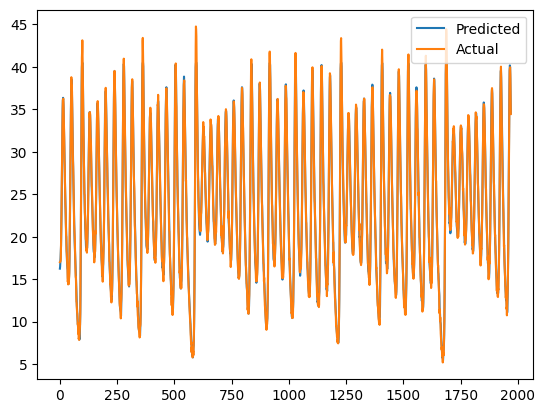

Rmse is 0.5777353418884086
[[[0.54185677 0.51097613 0.5291721 ]
  [0.53357767 0.55976475 0.50812598]
  [0.59275149 0.5849303  0.60575018]]

 [[0.53675046 0.57632424 0.54941318]
  [0.54860294 0.5512346  0.51779001]
  [0.55692145 0.55908133 0.56001111]]

 [[0.5585776  0.54437699 0.53238164]
  [0.57404713 0.55019098 0.5243818 ]
  [0.55134109 0.53186545 0.57773534]]]
Best RMSE: 0.508125977051213 with LSTM units=16, batch size=32, window size=30


In [ ]:
lstm_units = [16, 32, 64]
batch_size = [16, 32, 64]
window_sizes = [10, 20, 30]

rmse_values = np.zeros((len(lstm_units), len(batch_size), len(window_sizes)))
best_rmse = float('inf')
best_params = None

for i, unit in enumerate(lstm_units):
    for j, size in enumerate(batch_size):
        for k, previous_step in enumerate(window_sizes): 
            X_train, y_train = create_window(training, previous_step)
            X_validation, y_validation = create_window(validation, previous_step)

            X_train = X_train[..., np.newaxis]
            X_validation = X_validation[..., np.newaxis]

            lstm = models.Sequential([
                layers.LSTM(unit, activation = 'tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
                layers.Dense(1)
            ])
            lstm.compile(optimizer='adam', loss='mse')

            holdout = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
            historical_data = lstm.fit(X_train, y_train, epochs = 50, batch_size=size, validation_data=(X_validation, y_validation), callbacks=[holdout])
            predicted_values = lstm.predict(X_validation)
            pred = predicted_values.reshape(-1)
 

            plt.figure()
            plt.plot(pred, label='Predicted')
            plt.plot(y_validation, label='Actual')
            plt.legend()
            plt.show()

            rmse = calculate_rmse(predicted_values.flatten(), y_validation)
            print(f"Rmse is {rmse}")
            rmse_values[i][j][k] = rmse

            if rmse < best_rmse:
                best_rmse = rmse
                best_params = (unit, size, previous_step)

    

print(rmse_values)
#best_index = np.unravel_index(np.argmin(rmse_values), rmse_values.shape)

print(f"Best RMSE: {best_rmse} with LSTM units={best_params[0]}, batch size={best_params[1]}, window size={best_params[2]}")



In [ ]:
best_window_size = best_params[2]
X_train, y_train = create_window(training, best_window_size)
X_validation, y_validation = create_window(validation, best_window_size)   
X_test, y_test = create_window(testing, best_window_size)

X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

lstm = models.Sequential([
    layers.LSTM(best_params[0], activation = 'tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')
holdout = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
historical_data = lstm.fit(X_train, y_train, epochs = 50, batch_size=best_params[1], validation_data=(X_validation, y_validation), callbacks=[holdout])

predicted_test = lstm.predict(X_test)
test_rmse = np.sqrt(np.mean((y_test - predicted_test.flatten()) ** 2))

print(f"Test RMSE: {test_rmse}")

Best RMSE: 0.508 with LSTM units = 16, batch size = 32, window size =30

Epoch 1/50


c:\Users\Min Dator\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


312/312 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - loss: 451.7234 - val_loss: 299.1497
Epoch 2/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 223.8962 - val_loss: 173.5303
Epoch 3/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 140.6162 - val_loss: 112.5001
Epoch 4/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 91.8064 - val_loss: 74.2835
Epoch 5/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - loss: 57.2931 - val_loss: 44.2258
Epoch 6/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - loss: 35.4851 - val_loss: 28.5455
Epoch 7/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 23.1204 - val_loss: 18.8297
Epoch 8/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - loss: 15.3473 - val_loss: 12.5344
Epoch 9/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 11ms/step - loss: 10.3868 - val_loss: 8.5481
Epoch 10/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 10ms/step - loss: 7.1608 - val_loss: 5.9628
Epoch 11/50
312/312 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 5.0190 - val_loss: 4.2458
Epoch 12/50
312/312 ━━━━━━━━━━━━━━━━

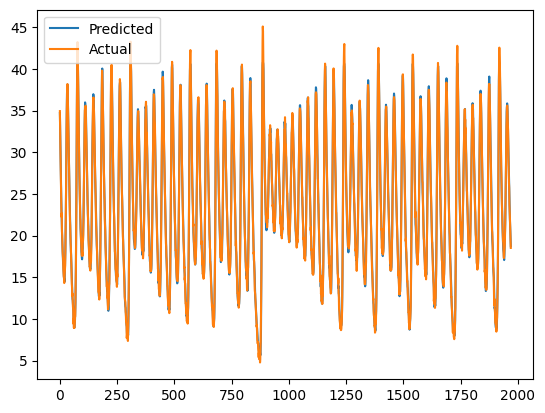

Rmse is 0.6061259136971651


In [ ]:
def calculate_rmse(predicted, actual):
    error = actual - predicted
    mse = np.mean(error ** 2)
    rmse = np.sqrt(mse)
    return rmse

window_size = 30
lstm_units = 16
batch_size = 32

X_train, y_train = create_window(training, window_size)
X_validation, y_validation = create_window(validation, window_size)
X_test, y_test = create_window(testing, window_size)

X_train = X_train[..., np.newaxis]
X_validation = X_validation[..., np.newaxis]
X_test = X_test[..., np.newaxis]

lstm = models.Sequential([
    layers.LSTM(lstm_units, activation = 'tanh', input_shape=(X_train.shape[1], X_train.shape[2])),
    layers.Dense(1)
])
lstm.compile(optimizer='adam', loss='mse')

holdout = callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True)
historical_data = lstm.fit(X_train, y_train, epochs = 50, batch_size=batch_size, validation_data=(X_validation, y_validation), callbacks=[holdout])

predicted_values = lstm.predict(X_test)
test_rmse = calculate_rmse(predicted_values.flatten(), y_test)
print(f"Test RMSE: {test_rmse}")


plt.figure()
plt.plot(predicted_values, label='Predicted')
plt.plot(y_test, label='Actual')
plt.xlabel("Time")
plt.ylabel("Value")
plt.title(f"Predicted vs. actual for LSTM, RMSE= {test_rmse:.4f}")
plt.legend()
plt.show()


print(f"Rmse is {calculate_rmse(predicted_values.flatten(), y_test)}")

An advantage with the linear model is that one can easily study and understand 
its structure. Consider your best ARMA model (Step 3), and provide a brief analysis 
of its structure (what previous time steps are most important? Which parameters 
are positive and which are negative? Why? ...and so on). Also, based both on the 
performance (RMSE error) and the interpretability, add a discussion comparing 
the two approaches (ARMA vs. LSTM) for this case

What I am uncertain about: 
- When doing ARMA, can I act like I know the actual value from one timestep ago, or do I have to estimate that somehow
- Should ACF and PACF be training or validation data? Have I interpreted them correctly?